In [1]:
"""
Created By    : Jared W. Marquis
Creation Date : 01 August 2022
Course        : ATSC 528 - Atmospheric Data Analysis
Assignment    : #01 - Function Fitting

Purpose:
Script to take sparse upper air observations and analyze them on a
polar stereographic map projection using function fitting.
[PUT MORE INFORMATION HERE - I.E., WHAT SPECIFIC THING IS BEING DONE]

"""
__author__    = "Jared W. Marquis"
__contact__   = "jared.marquis@und.edu"

Student Name: Austin Portner

In [2]:
### Import Required Modules (shouldn't need to change) ###
import numpy as np                 #numpy for math
import matplotlib.pyplot as plt    #matplotlib for plotting
import cartopy.crs as ccrs         #cartopy for plotting on map
import cartopy.feature as cfeature #cartopy basic shapefiles

In [3]:
### Read in observations ###

#Note path and file are for my computer only
path = 'C:/Users/austi/Desktop/AtSc_Masters_Classes/AtSc_528/Function_Fitting/'
file = 'RAOBs_201903131200.txt'
#path+file #Sanity check to ensure I have correct file path

In [4]:
### Set up analysis map with a 21x27 rectangular grid of points ###
lats, lons, hgts = [], [], []

with open(file, 'r') as f:
    for line in f:
        parts = line.strip().split(',')
        if len(parts) >=4:
            try:
                lat = float(parts[1])
                lon = float(parts[2])
                hgt = float(parts[3])
                # append valid observation data
                if not np.isnan(hgt):
                    lats.append(lat)
                    lons.append(lon)
                    hgts.append(hgt)
            except ValueError:
                continue

#Conversion to np arrays
obs_lat = np.array(lats)
obs_lon = np.array(lons)
obs_hgt = np.array(hgts)

# Now to setip 21x27 analysis grid
y, x = 27, 21
dx, dy = 1.27, 1.27 #in cm
x0, y0 = 25.0, -15.5 #in cm

# Now to generate 1D vectors and 2D meshgrid
grid_x_1d = x0 + np.arange(x) * dx
grid_y_1d = y0 + np.arange(y) * dy

grid_x_map, grid_y_map = np.meshgrid(grid_x_1d, grid_y_1d, indexing = 'ij')

In [5]:
### convert obs lat/long to x,y (may want to plot on your analysis grid to verify)###
# Doing pure math way to provide projection parameters
lambda_0 = -100.0
phi_0 = 60.0
rho = 6371229.0 
m = 1 / 15000000
R = rho * 100.0 * m

# Angles from lat/lon to radians
lat_rad = np.radians(obs_lat)
lon_rad = np.radians(obs_lon)
lambda_0_rad = np.radians(lambda_0)
phi_0_rad = np.radians(phi_0)

#conversion to cartesian coordinates in cm
sigma_obs = (1.0 + np.sin(phi_0_rad)) / (1.0 + np.sin(lat_rad))
obs_x = R * sigma_obs * np.cos(lat_rad) * np.cos(lon_rad - lambda_0_rad)
obs_y = R * sigma_obs * np.cos(lat_rad) * np.sin(lon_rad - lambda_0_rad)

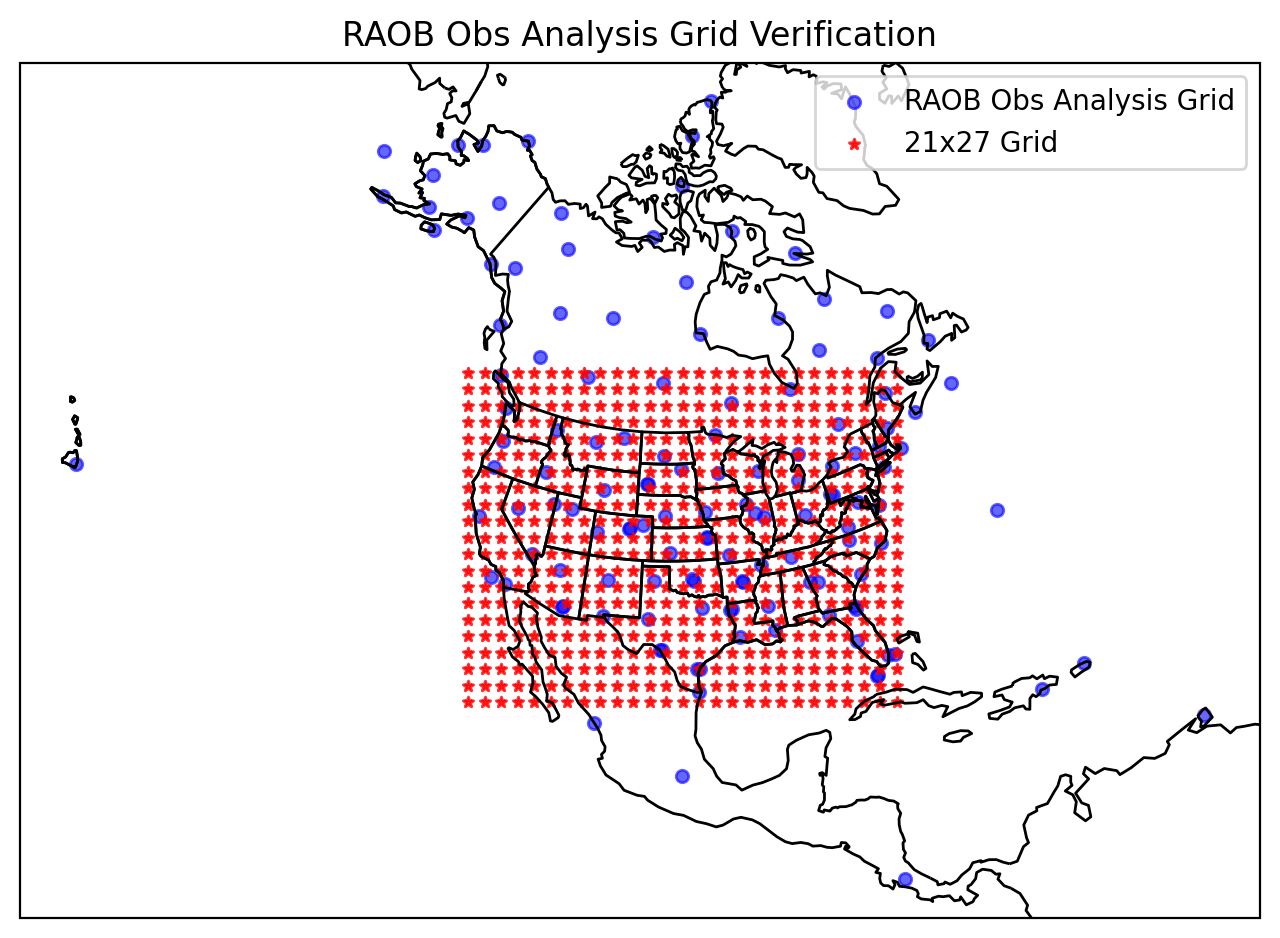

In [6]:
#Plt for sanity check
globe = ccrs.Globe(ellipse=None, semimajor_axis = rho, semiminor_axis = rho)
proj = ccrs.Stereographic(central_longitude=lambda_0,central_latitude=90,true_scale_latitude=phi_0,globe=globe)
fig = plt.figure(figsize=(8,8),dpi=200)
ax = fig.add_subplot(111,projection=proj)

#21x27 gridpoints
ax.scatter(obs_y / m / 100, -obs_x / m / 100, color = 'blue', s = 20, alpha = 0.6, label = 'RAOB Obs Analysis Grid', transform = proj)
ax.scatter(grid_y_map / m / 100, -grid_x_map / m / 100, color = 'red', s = 15, marker = '*', alpha = 0.8, label = '21x27 Grid', transform = proj)
ax.add_feature(cfeature.STATES)
ax.add_feature(cfeature.COASTLINE)

ax.set_xlabel('X-Coordinate (cm)')
ax.set_ylabel('Y-Coordinate (cm)')
ax.set_title('RAOB Obs Analysis Grid Verification')
ax.legend(loc = 'upper right')
ax.grid(True, linestyle = '--', alpha = 0.5)
ax.set_aspect('equal')
plt.show()

In [7]:
### Perform 500mb geopotential height analyses using a second order 2-d polynomial with two ###
### radii of influence (10cm & 20cm) ###
def obj_analysis_2nd_order_poly2d(obs_x, obs_y, obs_hgt, grid_x_map, grid_y_map, R_inf):
    """
    Performs a local objective analysis using Cressman distance weighting.
    """
    map_x_dim, map_y_dim = grid_x_map.shape # gets dimensions for polynomial
    grid_hgts_analysis = np.full((map_x_dim, map_y_dim), np.nan)
    grid_obs_counts = np.zeros((map_x_dim, map_y_dim), dtype = int)
    
    for i in range(map_x_dim):
        for j in range(map_y_dim):
            xg = grid_x_map[i, j]
            yg = grid_y_map[i, j]
            
            # relative distance from cuurent grid pts to all obs
            dx_dist = obs_x - xg
            dy_dist = obs_y - yg
            dist = np.sqrt(dx_dist**2 + dy_dist**2)
            
            # Obs filter within roi
            mask = dist <= R_inf
            n_obs = np.sum(mask)
            grid_obs_counts[i, j] = n_obs
            
            # 2D 2nd order poly (note: this requires min 6 pts to solve)
            if n_obs >= 6:
                dx_sub = dx_dist[mask]
                dy_sub = dy_dist[mask]
                hgt_sub = obs_hgt[mask]
                d_sub = dist[mask]
                
                # Cressman dist function
                weights = (R_inf**2 - d_sub**2) / (R_inf**2 + d_sub**2)
                
                # Matrix A (Note: formatting of code is for my understanding of what I wrote)
                A = np.column_stack([np.ones_like(dx_sub),
                    dx_sub, dy_sub,
                    dx_sub**2,
                    dy_sub**2,
                    dx_sub * dy_sub])
                
                # Weighted least squares needs the square root of weights performed
                w_sqrt = np.sqrt(weights)
                A_w = A * w_sqrt[:, None]
                b_w = hgt_sub * w_sqrt
                
                # Solving for c0, c1, c2, c3, c4, and c5 in the poly
                coeffs, _, _, _ = np.linalg.lstsq(A_w, b_w, rcond = None)
                
                # Value evaluated at grid center (dx = 0, dy = 0) is c0
                grid_hgts_analysis[i, j] = coeffs[0]

    return grid_hgts_analysis, grid_obs_counts

# Analysis for 10cm and 20cm
analysis_10cm, counts_10cm = obj_analysis_2nd_order_poly2d(obs_x, obs_y, obs_hgt, grid_x_map, grid_y_map, R_inf = 10.0)
analysis_20cm, counts_20cm = obj_analysis_2nd_order_poly2d(obs_x, obs_y, obs_hgt, grid_x_map, grid_y_map, R_inf = 20.0)

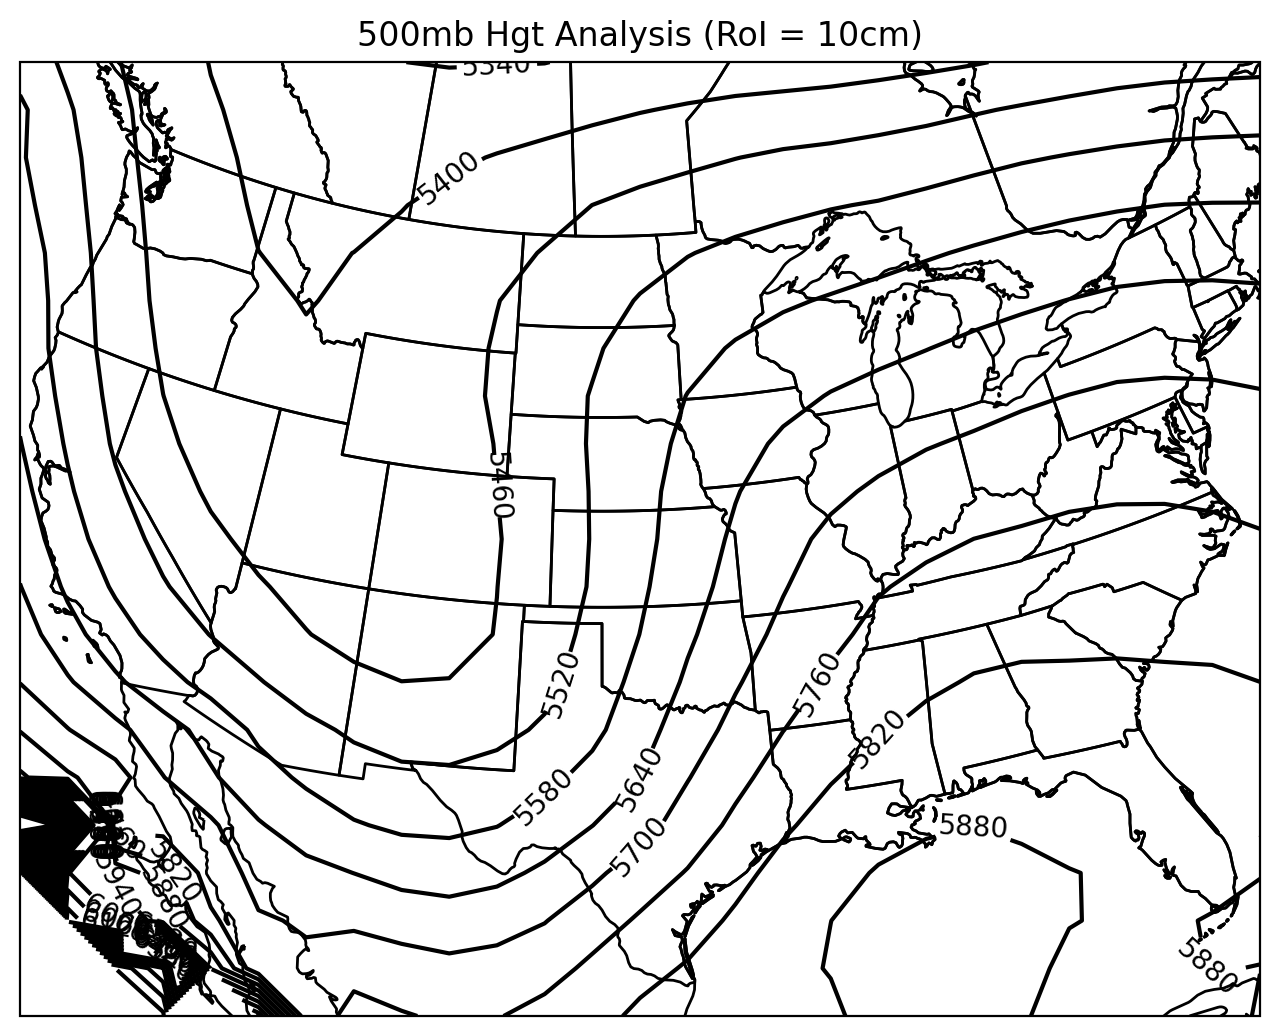

In [9]:
### Plot 500mb analyses over a map (10cm analysis) ###
globe = ccrs.Globe(ellipse=None, semimajor_axis=rho, semiminor_axis=rho)
proj = ccrs.Stereographic(central_longitude=lambda_0,central_latitude=90,true_scale_latitude=phi_0,globe=globe)
fig = plt.figure(figsize=(8,8),dpi=200)
ax1 = fig.add_subplot(111,projection=proj)

ax1.add_feature(cfeature.STATES)
ax1.add_feature(cfeature.COASTLINE)
# plot analysis (MAY NEED TO CHANGE VARIABLE NAMES/INDICES) #
cs1 = ax1.contour(grid_y_map/m/100,-grid_x_map/m/100,analysis_10cm,colors='k',levels=np.arange(0,8000,60),transform=proj)
plt.clabel(cs1,levels=np.arange(0,8000,60))
ax1.set_title('500mb Hgt Analysis (RoI = 10cm)')
plt.savefig('500mb_hgt_10cm.png', dpi = 300, bbox_inches = 'tight')

plt.show()

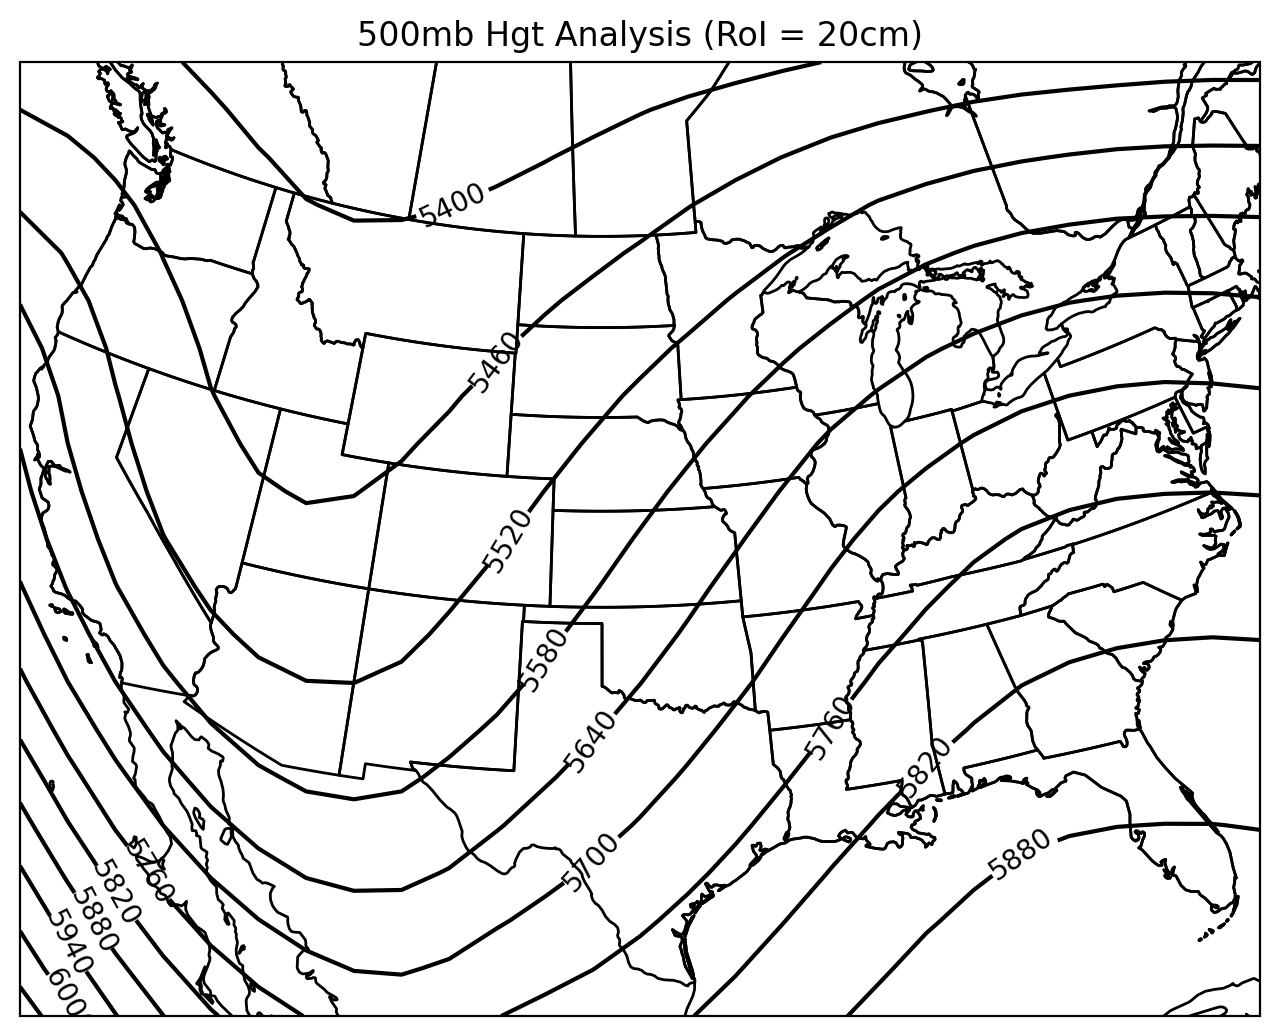

In [10]:
### Plot 500mb analyses over a map (20cm analysis) ###
globe = ccrs.Globe(ellipse=None, semimajor_axis=rho, semiminor_axis=rho)
proj = ccrs.Stereographic(central_longitude=lambda_0,central_latitude=90,true_scale_latitude=phi_0,globe=globe)
fig = plt.figure(figsize=(8,8),dpi=200)
ax1 = fig.add_subplot(111,projection=proj)

ax1.add_feature(cfeature.STATES)
ax1.add_feature(cfeature.COASTLINE)
# plot analysis (MAY NEED TO CHANGE VARIABLE NAMES/INDICES) #
cs1 = ax1.contour(grid_y_map/m/100,-grid_x_map/m/100,analysis_20cm,colors='k',levels=np.arange(0,8000,60),transform=proj)
plt.clabel(cs1,levels=np.arange(0,8000,60))
ax1.set_title('500mb Hgt Analysis (RoI = 20cm)')
plt.savefig('500mb_hgt_20cm.png', dpi = 300, bbox_inches = 'tight')

plt.show()

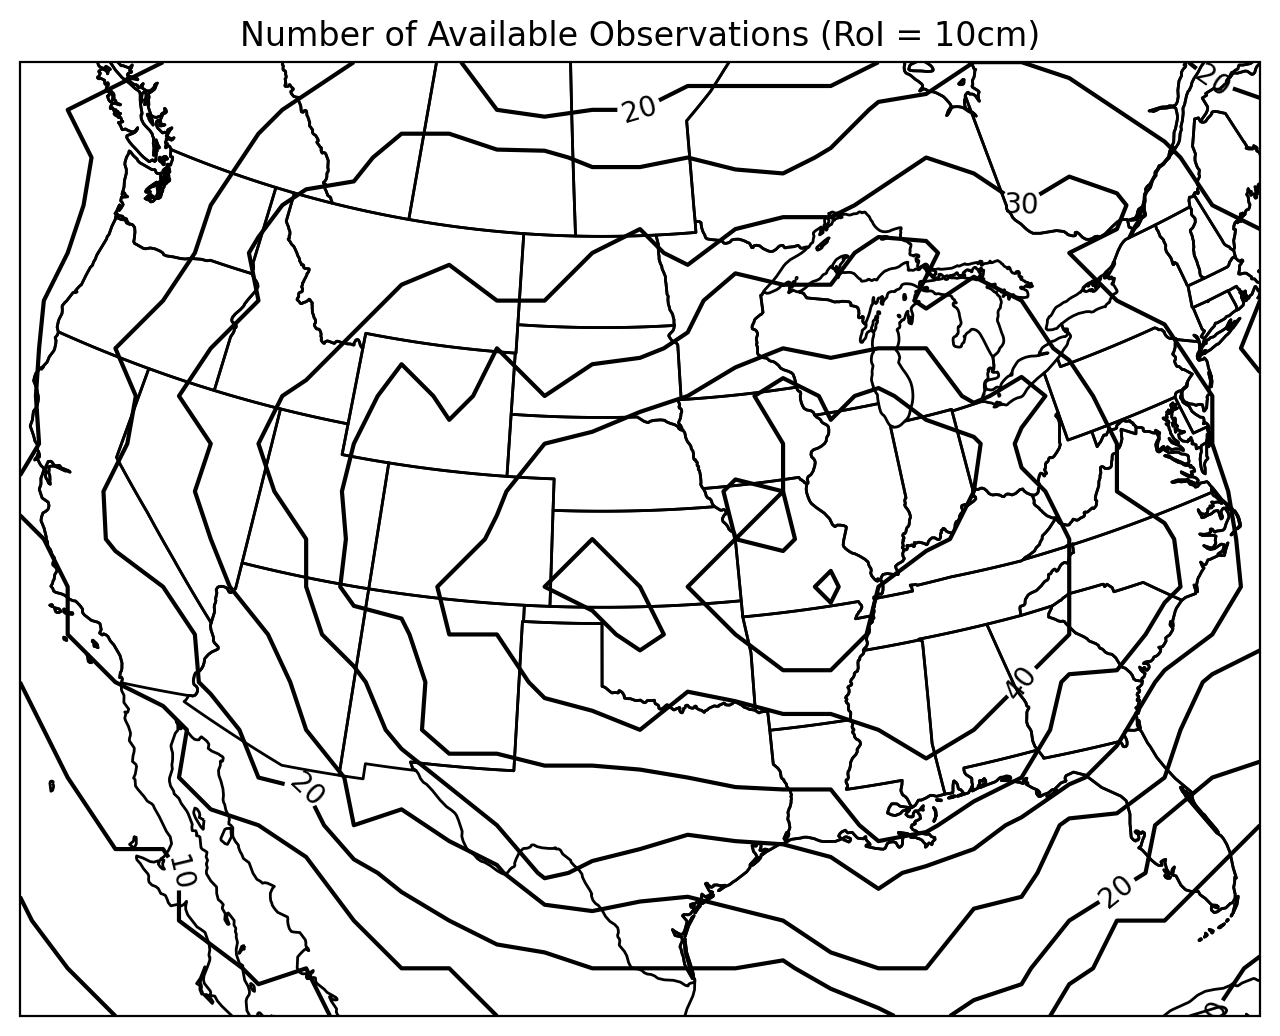

In [11]:
### Plot number of observations available to polynomial fitting scheme for each grid point ###
globe = ccrs.Globe(ellipse=None, semimajor_axis=rho, semiminor_axis=rho)
proj = ccrs.Stereographic(central_longitude=lambda_0,central_latitude=90,true_scale_latitude=phi_0,globe=globe)
fig = plt.figure(figsize=(8,8),dpi=200)
ax1 = fig.add_subplot(111,projection=proj)
ax1.add_feature(cfeature.STATES)
ax1.add_feature(cfeature.COASTLINE)
# plot number of observations (MAY NEED TO CHANGE VARIABLE NAMES/INDICES) #
cs1 = ax1.contour(grid_y_map/m/100,-grid_x_map/m/100,counts_10cm,colors='k',levels=np.arange(0,200,5),transform=proj)
plt.clabel(cs1,levels=np.arange(0,200,10))
ax1.set_title('Number of Available Observations (RoI = 10cm)')
plt.savefig('obs_counts_10cm.png', dpi = 300, bbox_inches = 'tight')

plt.show()

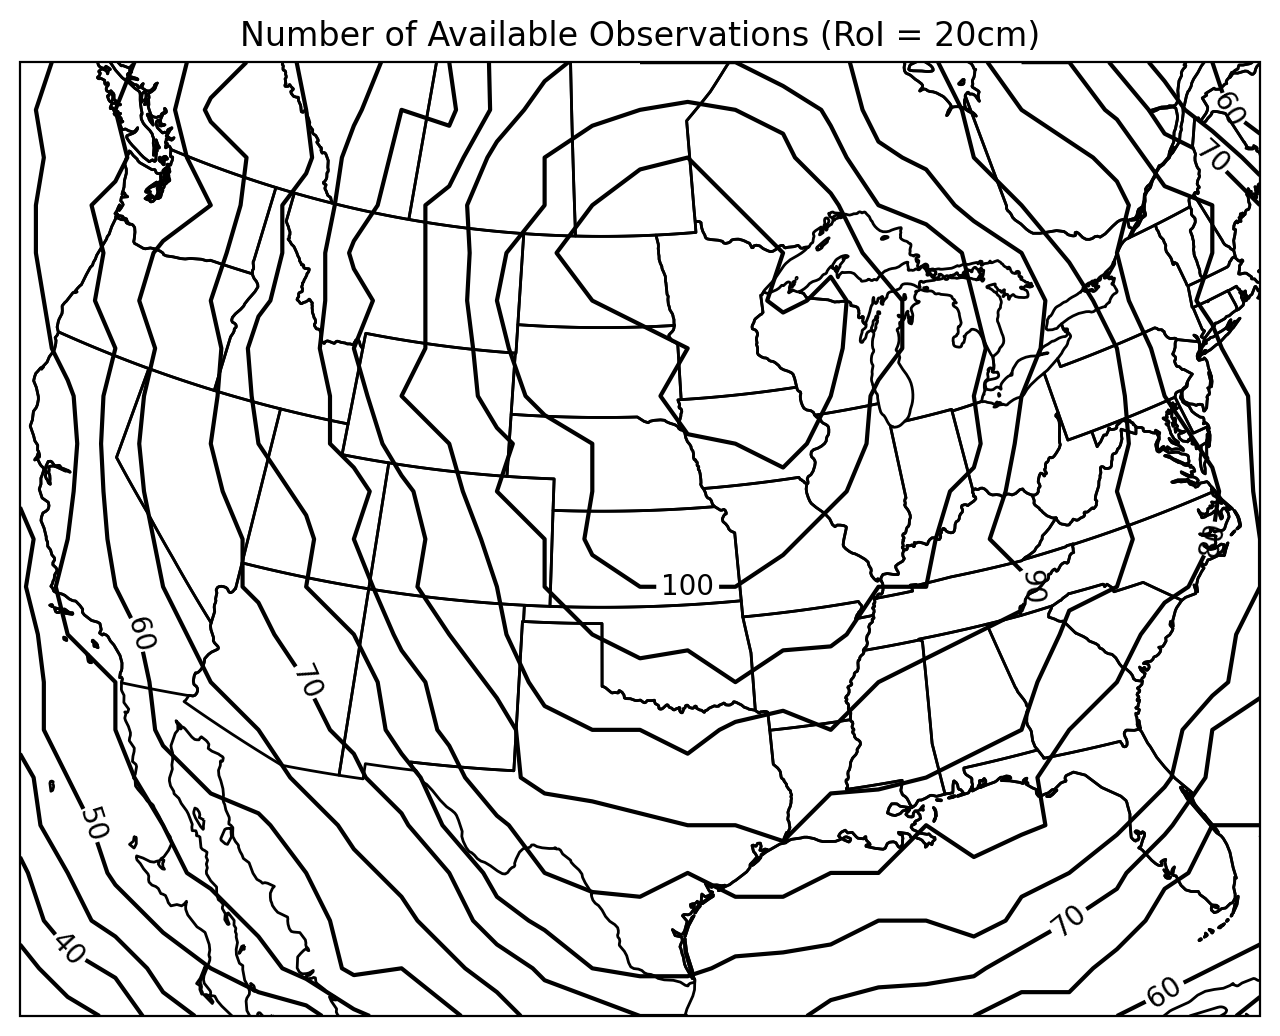

In [12]:
### Plot number of observations available to polynomial fitting scheme for each grid point ###
globe = ccrs.Globe(ellipse=None, semimajor_axis=rho, semiminor_axis=rho)
proj = ccrs.Stereographic(central_longitude=lambda_0,central_latitude=90,true_scale_latitude=phi_0,globe=globe)
fig = plt.figure(figsize=(8,8),dpi=200)
ax1 = fig.add_subplot(111,projection=proj)
ax1.add_feature(cfeature.STATES)
ax1.add_feature(cfeature.COASTLINE)
# plot number of observations (MAY NEED TO CHANGE VARIABLE NAMES/INDICES) #
cs1 = ax1.contour(grid_y_map/m/100,-grid_x_map/m/100,counts_20cm,colors='k',levels=np.arange(0,200,5),transform=proj)
plt.clabel(cs1,levels=np.arange(0,200,10))
ax1.set_title('Number of Available Observations (RoI = 20cm)')
plt.savefig('obs_counts_20cm.png', dpi = 300, bbox_inches = 'tight')

plt.show()

In [13]:
### Store the analyses in text files ###

np.savetxt('analysis_10cm', analysis_10cm, fmt = '%.2f', header = '500mb Hgt Analysis (RoI = 10cm)')
np.savetxt('analysis_20cm', analysis_20cm, fmt = '%.2f', header = '500mb Hgt Analysis (RoI = 20cm)')

In [14]:
### Store the number of observations available for each grid point in text files ###

np.savetxt('counts_10cm', counts_10cm, fmt = '%d', header = 'Number of Available Observations (RoI = 10cm)')
np.savetxt('counts_20cm', counts_20cm, fmt = '%d', header = 'Number of Available Observations (RoI = 20cm)')

In [ ]:
### In a separte text file (or below), answer the following questions ###
'''
1 - Describe the general features that you see in your contoured analyses.
    

2 - Describe the differences that you see in your contoured analyses.  
    Does one analysis seem to be smoother than the other?  If so, what would cause this?
    

3 - Run your program using a radius of influence of 6 cm (do not need to show).  
    Describe the results - do they look realistic?  If there are problems, what
    do you think might be causing them?
    

4 - Suppose you ran this program with a small enough radius of influence that only one
    observation was available for determining a polynomial fit at a grid point.  Should
    you be able to perform the matrix inversion?  Why or why not?
    

'''